# Embedding + Retrieval Model Comparison — 5 Models

Benchmarks 6 frozen embedding models on the **retrieval** approach discussed:
instead of training a fixed-class classifier, each model converts every photo
into a numeric embedding, and new items are recognized by finding the
**nearest stored embedding** — the architecture that lets you add new
inventory (e.g. item `5001`) without retraining anything.

**Models compared:**
1. CLIP ViT-B/32 (OpenAI)
2. OpenCLIP ViT-B/32 (LAION-2B)
3. SigLIP (base, patch16, 224px)
4. DINOv2 (base) — self-supervised, no text pretraining, strong at fine-grained visual similarity
5. YOLO-World — included as the YOLO representative; **not a natural fit** for this task
   (it's an open-vocabulary *detector*, not a similarity/embedding model) — kept in for a fair,
   honest comparison rather than assuming it will underperform

**NVIDIA C-RADIO was evaluated but removed** — the `RadioModel` class isn't available in the
transformers version currently installed on Kaggle (it's a very recent addition), so it fails
to import there. Not worth chasing a library-version mismatch for this comparison.

**Evaluation:** same leakage-safe split as prior notebooks — each item's one real
photo is held out as the *query*; augmented variants build the *gallery* (the
stored reference embeddings). A query is scored correct if its nearest gallery
item(s) match the real `products_id`.

**Also measured, for the eventual API-hosted deployment (e.g. Replicate) this is
heading toward:** patch/token count per image, embedding dimension, model size,
inference latency, and estimated **$ cost per 1,000 image searches** across GPU
tiers — real Replicate per-second GPU pricing as of mid-2026, so these numbers
can go directly into a client-facing cost conversation.

**At the end:** the top 3 models (by weighted score) get their weights + the
precomputed gallery embeddings zipped and saved to `/kaggle/working/` for
download, ready to plug into the CLIP-style test website.

**Dataset path:**
```
/kaggle/input/datasets/datascientist97/locomotive-collection-images/conductor_dataset
```

## 0. Setup

In [29]:
!pip install -q ultralytics
# NOTE: deliberately not touching torch/torchvision/transformers with --upgrade —
# Kaggle's preinstalled versions are matched to the assigned GPU. See the earlier
# notebooks in this project for why this matters (CUDA kernel mismatch errors).

In [30]:
import os
import time
import json
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn.functional as F

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

FORCE_CPU = False
DEVICE = torch.device('cpu') if FORCE_CPU else torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', DEVICE)

if torch.cuda.is_available() and not FORCE_CPU:
    try:
        t = torch.randn(2, 2).cuda(); _ = t @ t
        print('✅ GPU tensor op succeeded.')
    except Exception as e:
        print('❌ GPU broken — set FORCE_CPU = True above, or switch Accelerator type',
              '(e.g. P100 -> T4) in Kaggle settings.')
        print('Error:', e)

Using device: cuda
✅ GPU tensor op succeeded.


In [31]:
DATASET_ROOT = "/kaggle/input/datasets/datascientist97/locomotive-collection-images/conductor_dataset"
CATEGORIES = ["Locomotives", "Passenger Train Cars", "Freight Cars", "Automobiles"]
IMG_SIZE = 224
TOP_K = 3

# Real Replicate per-second GPU pricing (mid-2026) — used later for cost estimates
GPU_PRICING_PER_SEC = {
    'T4': 0.000225,
    'L40S': 0.000975,
    'A100 80GB': 0.001400,
    'H100': 0.001525,
}

## 1. Build the Leakage-Safe Gallery / Query Split

Same rule as the classifier notebooks: each item's one real photo becomes the
**query** set; its augmented variants become the **gallery** (what gets
embedded and stored as the known reference).

In [32]:
VALID_EXTS = {'.jpg', '.jpeg', '.png', '.webp'}
MIN_GALLERY_IMAGES = 1  # retrieval only strictly needs >=1 gallery image per item, unlike classifiers

records = []
for category in CATEGORIES:
    cat_path = os.path.join(DATASET_ROOT, category)
    if not os.path.isdir(cat_path):
        continue
    for products_id in sorted(os.listdir(cat_path)):
        folder = os.path.join(cat_path, products_id)
        if not os.path.isdir(folder):
            continue
        real_files, aug_files = [], []
        for fname in sorted(os.listdir(folder)):
            ext = os.path.splitext(fname)[1].lower()
            if ext not in VALID_EXTS:
                continue
            (aug_files if '_aug_' in fname else real_files).append(fname)
        if not real_files or len(aug_files) < MIN_GALLERY_IMAGES:
            continue
        records.append({'category': category, 'products_id': products_id,
                         'path': os.path.join(folder, real_files[0]), 'split': 'query'})
        for f in aug_files:
            records.append({'category': category, 'products_id': products_id,
                             'path': os.path.join(folder, f), 'split': 'gallery'})

split_df = pd.DataFrame(records)
gallery_df = split_df[split_df['split'] == 'gallery'].reset_index(drop=True)
query_df = split_df[split_df['split'] == 'query'].reset_index(drop=True)

NUM_ITEMS = split_df['products_id'].nunique()
print(f"Items with a usable gallery+query pair: {NUM_ITEMS}")
print(f"Gallery images: {len(gallery_df)} | Query images: {len(query_df)}")

Items with a usable gallery+query pair: 827
Gallery images: 3308 | Query images: 827


## 2. Shared Evaluation Harness

One function used for every model: given a function that embeds a batch of
PIL images, this builds the gallery index (averaging each item's gallery
embeddings into one 'prototype' vector), embeds all queries, and computes
retrieval metrics — identical procedure for every model, so results are fair.

In [33]:
def get_pooled_features(output):
    """Handles whatever shape a model's image-feature call returns —
    a plain tensor, or an object wrapping it (e.g. BaseModelOutputWithPooling,
    common with newer transformers versions on CLIP-family models). Tries,
    in order: raw tensor, .image_embeds, .pooler_output, then falls back to
    mean-pooling .last_hidden_state."""
    if isinstance(output, torch.Tensor):
        return output
    if hasattr(output, 'image_embeds') and output.image_embeds is not None:
        return output.image_embeds
    if hasattr(output, 'pooler_output') and output.pooler_output is not None:
        return output.pooler_output
    if hasattr(output, 'last_hidden_state'):
        return output.last_hidden_state.mean(dim=1)
    raise TypeError(f"Unrecognized model output type: {type(output)}")


def l2_normalize(x):
    return x / (np.linalg.norm(x, axis=1, keepdims=True) + 1e-8)

def build_gallery_index(embed_fn, gallery_df, batch_size=32):
    """Embeds every gallery image, then averages per products_id into one
    prototype vector — the 'known reference' for that item."""
    all_embeds, all_pids = [], []
    paths = gallery_df['path'].tolist()
    pids = gallery_df['products_id'].tolist()
    for i in range(0, len(paths), batch_size):
        batch_paths = paths[i:i+batch_size]
        batch_pids = pids[i:i+batch_size]
        images = [Image.open(p).convert('RGB') for p in batch_paths]
        embeds = embed_fn(images)
        all_embeds.append(embeds)
        all_pids.extend(batch_pids)
    all_embeds = np.concatenate(all_embeds, axis=0)

    proto_df = pd.DataFrame({'products_id': all_pids})
    unique_pids = proto_df['products_id'].unique()
    prototypes = np.zeros((len(unique_pids), all_embeds.shape[1]), dtype=np.float32)
    for i, pid in enumerate(unique_pids):
        mask = proto_df['products_id'].values == pid
        prototypes[i] = all_embeds[mask].mean(axis=0)

    prototypes = l2_normalize(prototypes)
    return prototypes, list(unique_pids)

def evaluate_retrieval(embed_fn, gallery_df, query_df, top_k=TOP_K, batch_size=32):
    gallery_start = time.time()
    prototypes, proto_pids = build_gallery_index(embed_fn, gallery_df, batch_size)
    gallery_time = time.time() - gallery_start

    query_paths = query_df['path'].tolist()
    query_pids = query_df['products_id'].tolist()

    query_start = time.time()
    query_embeds = []
    for i in range(0, len(query_paths), batch_size):
        images = [Image.open(p).convert('RGB') for p in query_paths[i:i+batch_size]]
        query_embeds.append(embed_fn(images))
    query_embeds = l2_normalize(np.concatenate(query_embeds, axis=0))
    query_time = time.time() - query_start
    per_image_ms = (query_time / len(query_paths)) * 1000

    # Cosine similarity (both sides L2-normalized, so this is just a dot product)
    sims = query_embeds @ prototypes.T  # (num_queries, num_items)

    top1_correct, top3_correct, reciprocal_ranks = 0, 0, []
    for i, true_pid in enumerate(query_pids):
        ranking = np.argsort(sims[i])[::-1]
        ranked_pids = [proto_pids[j] for j in ranking]
        rank_of_true = ranked_pids.index(true_pid) + 1 if true_pid in ranked_pids else len(ranked_pids) + 1
        reciprocal_ranks.append(1.0 / rank_of_true)
        if ranked_pids[0] == true_pid:
            top1_correct += 1
        if true_pid in ranked_pids[:top_k]:
            top3_correct += 1

    n = len(query_pids)
    return {
        'top1_acc': top1_correct / n,
        'top3_acc': top3_correct / n,
        'mrr': float(np.mean(reciprocal_ranks)),
        'embedding_dim': prototypes.shape[1],
        'gallery_build_time_sec': gallery_time,
        'query_time_ms_per_image': per_image_ms,
        'num_gallery_images': len(gallery_df),
        'num_queries': n,
    }

## 3. Model Loaders

One `embed_fn(images) -> np.ndarray` per model, all sharing the same
interface so `evaluate_retrieval` above works identically for every model.

In [34]:
def count_params(model):
    return sum(p.numel() for p in model.parameters())

def model_size_mb(model):
    tmp = '_tmp_size.pt'
    torch.save(model.state_dict(), tmp)
    size = os.path.getsize(tmp) / (1024*1024)
    os.remove(tmp)
    return size

In [35]:
# ---- 1. CLIP (OpenAI) ----
def setup_clip():
    from transformers import CLIPModel, CLIPProcessor
    model = CLIPModel.from_pretrained('openai/clip-vit-base-patch32').to(DEVICE).eval()
    processor = CLIPProcessor.from_pretrained('openai/clip-vit-base-patch32')

    def embed_fn(images):
        inputs = processor(images=images, return_tensors='pt').to(DEVICE)
        with torch.no_grad():
            raw_out = model.get_image_features(**inputs)
        return get_pooled_features(raw_out).cpu().numpy()

    patch_size, img_size = 32, 224
    num_patches = (img_size // patch_size) ** 2 + 1  # +1 for CLS token
    info = {'total_params': count_params(model), 'model_size_mb': model_size_mb(model),
            'patch_tokens_per_image': num_patches, 'architecture': 'ViT (CLIP)'}
    return embed_fn, info

In [36]:
# ---- 2. OpenCLIP (LAION-2B) ----
def setup_openclip():
    from transformers import CLIPModel, CLIPProcessor
    repo = 'laion/CLIP-ViT-B-32-laion2B-s34B-b79K'
    model = CLIPModel.from_pretrained(repo).to(DEVICE).eval()
    processor = CLIPProcessor.from_pretrained(repo)

    def embed_fn(images):
        inputs = processor(images=images, return_tensors='pt').to(DEVICE)
        with torch.no_grad():
            raw_out = model.get_image_features(**inputs)
        return get_pooled_features(raw_out).cpu().numpy()

    patch_size, img_size = 32, 224
    num_patches = (img_size // patch_size) ** 2 + 1
    info = {'total_params': count_params(model), 'model_size_mb': model_size_mb(model),
            'patch_tokens_per_image': num_patches, 'architecture': 'ViT (OpenCLIP/LAION)'}
    return embed_fn, info

In [37]:
# ---- 3. SigLIP ----
def setup_siglip():
    from transformers import SiglipModel, SiglipProcessor
    repo = 'google/siglip-base-patch16-224'
    model = SiglipModel.from_pretrained(repo).to(DEVICE).eval()
    processor = SiglipProcessor.from_pretrained(repo)

    def embed_fn(images):
        inputs = processor(images=images, return_tensors='pt').to(DEVICE)
        with torch.no_grad():
            raw_out = model.get_image_features(**inputs)
        return get_pooled_features(raw_out).cpu().numpy()

    patch_size, img_size = 16, 224
    num_patches = (img_size // patch_size) ** 2  # SigLIP has no CLS token — pure patch tokens
    info = {'total_params': count_params(model), 'model_size_mb': model_size_mb(model),
            'patch_tokens_per_image': num_patches, 'architecture': 'ViT (SigLIP)'}
    return embed_fn, info

In [38]:
# ---- 4. DINOv2 ----
def setup_dinov2():
    from transformers import AutoModel, AutoImageProcessor
    repo = 'facebook/dinov2-base'
    model = AutoModel.from_pretrained(repo).to(DEVICE).eval()
    processor = AutoImageProcessor.from_pretrained(repo)

    def embed_fn(images):
        inputs = processor(images=images, return_tensors='pt').to(DEVICE)
        with torch.no_grad():
            out = model(**inputs)
        # DINOv2's pooled CLS-token representation — the standard choice
        # for image-level embedding/retrieval tasks with this model.
        return out.pooler_output.cpu().numpy()

    patch_size, img_size = 14, 224
    num_patches = (img_size // patch_size) ** 2 + 1
    info = {'total_params': count_params(model), 'model_size_mb': model_size_mb(model),
            'patch_tokens_per_image': num_patches, 'architecture': 'ViT (DINOv2, self-supervised)'}
    return embed_fn, info

In [39]:
# ---- 5. YOLO-World ----
# Genuinely not a natural fit for this task — YOLO-World is an open-vocabulary
# OBJECT DETECTOR, not an embedding/similarity model. There is no official,
# standard way to pull a single whole-image embedding out of it. This
# extracts one via global-average-pooling an intermediate backbone feature map,
# which is a reasonable but non-standard improvisation — included for a fair,
# honest comparison rather than assuming it will underperform without testing.
#
# IMPORTANT FIX: YOLO's architecture has skip-connections/concatenations
# between non-adjacent layers (like an FPN), so its submodules can NOT be
# called as a plain nn.Sequential — doing so breaks the internal routing
# (this caused the earlier 'cat() invalid combination of arguments' crash).
# The fix is to run inference through Ultralytics' own model.predict(),
# which correctly handles that routing, while a forward hook captures the
# intermediate feature map we actually want, as a side effect of that call.
def setup_yolo_world():
    from ultralytics import YOLO
    model = YOLO('yolov8s-worldv2.pt')
    model.to(DEVICE)

    backbone_layers = model.model.model
    feature_layer_idx = 9  # SPPF layer — last pure-backbone stage before the detection head

    captured = {}
    def hook(module, inp, out):
        captured['feat'] = out
    handle = backbone_layers[feature_layer_idx].register_forward_hook(hook)

    def embed_fn(images):
        # Ultralytics' predict() does its own preprocessing (letterbox resize,
        # normalization) and correctly threads the model's internal skip
        # connections — do not bypass it by calling submodules directly.
        _ = model.predict(source=list(images), verbose=False, save=False, device=DEVICE)
        feat = captured['feat']  # (B, C, H, W), captured via the hook above
        pooled = F.adaptive_avg_pool2d(feat, 1).flatten(1)  # global average pool -> (B, C)
        return pooled.detach().cpu().numpy()

    info = {'total_params': count_params(backbone_layers), 'model_size_mb': model_size_mb(backbone_layers),
            'patch_tokens_per_image': None,  # CNN, not a patch-token architecture — reported as N/A
            'architecture': 'CNN (YOLOv8-World backbone, improvised embedding)'}
    return embed_fn, info

## 4. Run All 5 Models

In [40]:
MODEL_SETUPS = {
    'CLIP ViT-B/32': setup_clip,
    'OpenCLIP ViT-B/32 (LAION)': setup_openclip,
    'SigLIP Base': setup_siglip,
    'DINOv2 Base': setup_dinov2,
    'YOLO-World (improvised embedding)': setup_yolo_world,
}

all_results = []

for model_name, setup_fn in MODEL_SETUPS.items():
    print(f"\n{'='*60}\n{model_name}\n{'='*60}")
    try:
        embed_fn, info = setup_fn()
        metrics = evaluate_retrieval(embed_fn, gallery_df, query_df)

        n = metrics['num_queries']
        est_total_search_time_sec = (metrics['query_time_ms_per_image'] / 1000)
        result = {'model_name': model_name, **info, **metrics}
        for gpu, rate in GPU_PRICING_PER_SEC.items():
            result[f'cost_per_1000_searches_{gpu}'] = est_total_search_time_sec * 1000 * rate
        all_results.append(result)

        print(f"  Top-1: {metrics['top1_acc']:.3f} | Top-3: {metrics['top3_acc']:.3f} | "
              f"MRR: {metrics['mrr']:.3f} | {metrics['query_time_ms_per_image']:.2f} ms/image")

        del embed_fn
        if DEVICE.type == 'cuda':
            torch.cuda.empty_cache()

    except Exception as e:
        print(f"  ⚠️ SKIPPED — {model_name} failed to load or run: {e}")
        all_results.append({'model_name': model_name, 'error': str(e)})

print(f"\n\n✅ Finished. {sum(1 for r in all_results if 'error' not in r)}/{len(MODEL_SETUPS)} models evaluated successfully.")


CLIP ViT-B/32


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Top-1: 0.925 | Top-3: 0.990 | MRR: 0.958 | 5.30 ms/image

OpenCLIP ViT-B/32 (LAION)


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

...

  Top-1: 0.935 | Top-3: 0.994 | MRR: 0.963 | 5.33 ms/image

SigLIP Base


Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

  Top-1: 0.940 | Top-3: 0.995 | MRR: 0.967 | 14.24 ms/image

DINOv2 Base


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

  Top-1: 0.940 | Top-3: 0.994 | MRR: 0.967 | 18.13 ms/image

YOLO-World (improvised embedding)
  Top-1: 0.520 | Top-3: 0.629 | MRR: 0.592 | 14.48 ms/image


✅ Finished. 5/5 models evaluated successfully.


## 5. Results Table

In [41]:
results_df = pd.DataFrame([r for r in all_results if 'error' not in r])
failed_df = pd.DataFrame([r for r in all_results if 'error' in r])

if len(failed_df):
    print('⚠️ Models that failed to run (see errors above for why):')
    print(failed_df[['model_name', 'error']])
    print()

results_df = results_df.sort_values('top1_acc', ascending=False).reset_index(drop=True)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 250)

display_cols = ['model_name', 'top1_acc', 'top3_acc', 'mrr', 'embedding_dim',
                 'patch_tokens_per_image', 'model_size_mb', 'total_params',
                 'query_time_ms_per_image', 'cost_per_1000_searches_T4']
results_df[display_cols].round(4)

,model_name,top1_acc,top3_acc,mrr,embedding_dim,patch_tokens_per_image,model_size_mb,total_params,query_time_ms_per_image,cost_per_1000_searches_T4
0,SigLIP Base,0.9395,0.9952,0.9672,768,196.0,775.1300,203155970,14.2384,0.0032
1,DINOv2 Base,0.9395,0.9940,0.9671,768,257.0,330.3601,86580480,18.1289,0.0041
2,OpenCLIP ViT-B/32 (LAION),0.9347,0.9940,0.9633,512,50.0,577.2252,151277313,5.3253,0.0012
3,CLIP ViT-B/32,0.9250,0.9903,0.9578,512,50.0,577.2252,151277313,5.3002,0.0012
4,YOLO-World (improvised embedding),0.5200,0.6288,0.5919,512,NaN,48.9000,12759880,14.4837,0.0033


In [42]:
results_df.to_csv('retrieval_model_comparison_results.csv', index=False)
print('Saved full results to retrieval_model_comparison_results.csv')

Saved full results to retrieval_model_comparison_results.csv


## 6. Retrieval Accuracy Comparison

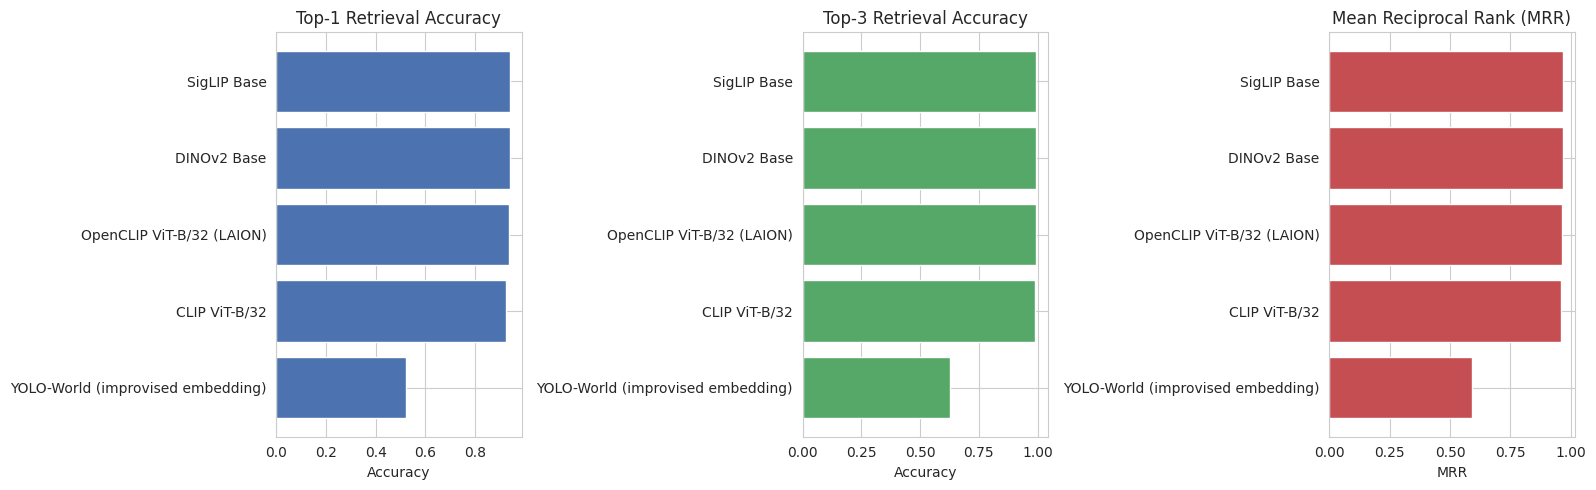

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sorted_df = results_df.sort_values('top1_acc')
axes[0].barh(sorted_df['model_name'], sorted_df['top1_acc'], color='#4C72B0')
axes[0].set_title('Top-1 Retrieval Accuracy')
axes[0].set_xlabel('Accuracy')

sorted_df3 = results_df.sort_values('top3_acc')
axes[1].barh(sorted_df3['model_name'], sorted_df3['top3_acc'], color='#55A868')
axes[1].set_title('Top-3 Retrieval Accuracy')
axes[1].set_xlabel('Accuracy')

sorted_mrr = results_df.sort_values('mrr')
axes[2].barh(sorted_mrr['model_name'], sorted_mrr['mrr'], color='#C44E52')
axes[2].set_title('Mean Reciprocal Rank (MRR)')
axes[2].set_xlabel('MRR')

plt.tight_layout()
plt.show()

## 7. Efficiency & Token/Cost Comparison

This section is the one to show a client — real GPU-second pricing (Replicate,
mid-2026) applied to each model's measured inference speed.

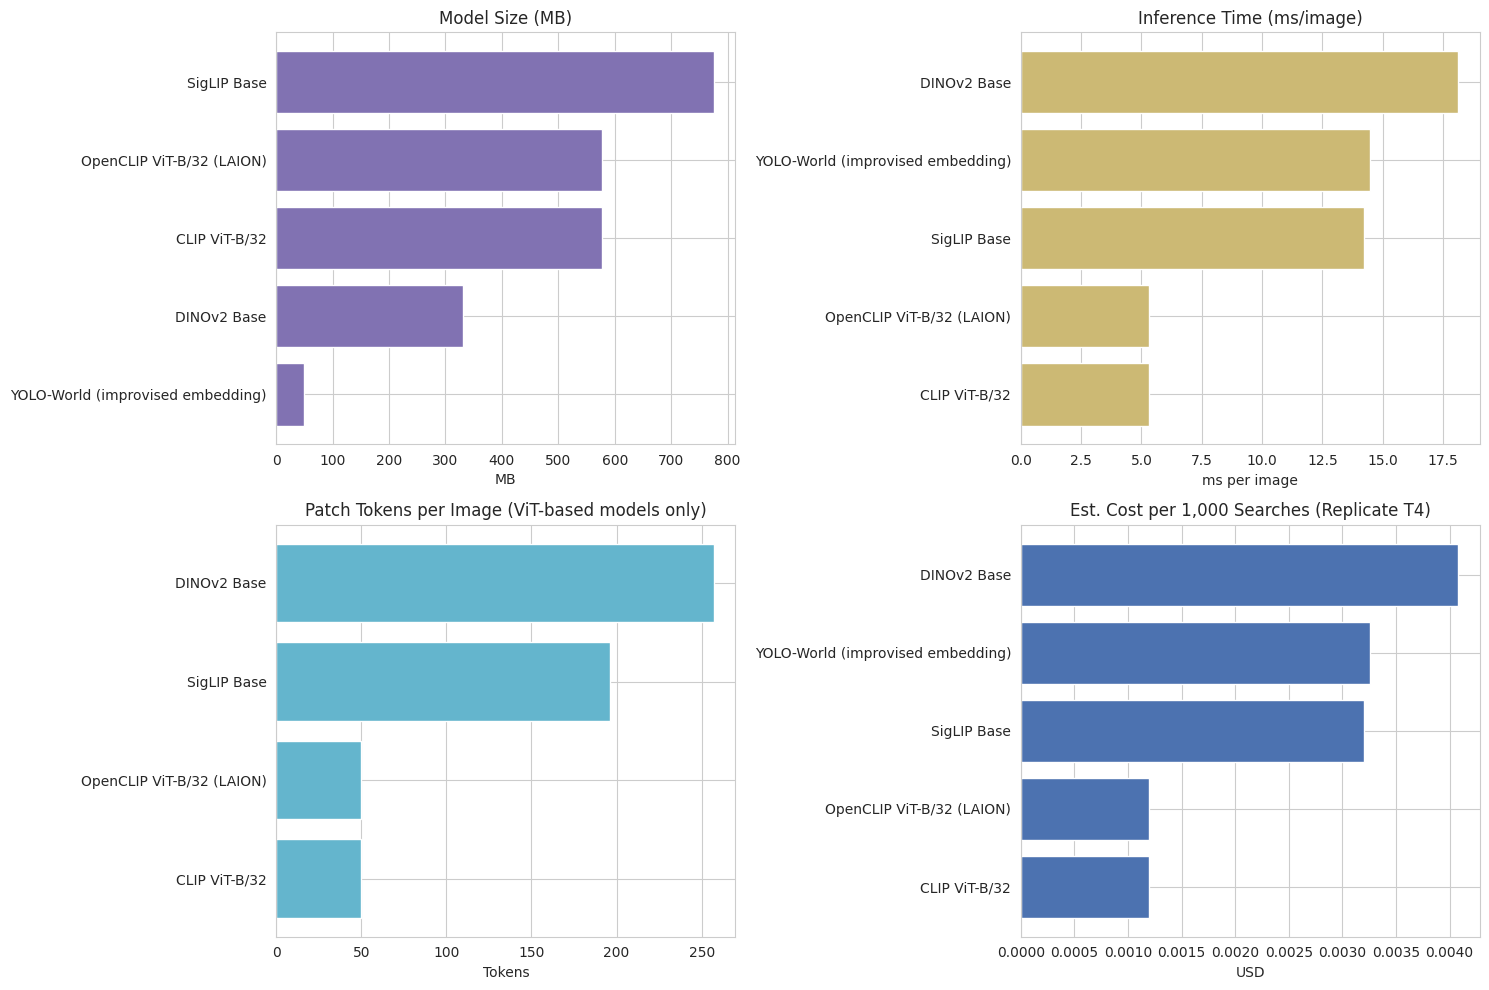

In [44]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sorted_size = results_df.sort_values('model_size_mb')
axes[0,0].barh(sorted_size['model_name'], sorted_size['model_size_mb'], color='#8172B2')
axes[0,0].set_title('Model Size (MB)')
axes[0,0].set_xlabel('MB')

sorted_speed = results_df.sort_values('query_time_ms_per_image')
axes[0,1].barh(sorted_speed['model_name'], sorted_speed['query_time_ms_per_image'], color='#CCB974')
axes[0,1].set_title('Inference Time (ms/image)')
axes[0,1].set_xlabel('ms per image')

token_df = results_df.dropna(subset=['patch_tokens_per_image'])
sorted_tokens = token_df.sort_values('patch_tokens_per_image')
axes[1,0].barh(sorted_tokens['model_name'], sorted_tokens['patch_tokens_per_image'], color='#64B5CD')
axes[1,0].set_title('Patch Tokens per Image (ViT-based models only)')
axes[1,0].set_xlabel('Tokens')

sorted_cost = results_df.sort_values('cost_per_1000_searches_T4')
axes[1,1].barh(sorted_cost['model_name'], sorted_cost['cost_per_1000_searches_T4'], color='#4C72B0')
axes[1,1].set_title('Est. Cost per 1,000 Searches (Replicate T4)')
axes[1,1].set_xlabel('USD')

plt.tight_layout()
plt.show()

In [45]:
# Cost across all 4 GPU tiers — the direct 'what will this cost per search' table for the client
cost_cols = [c for c in results_df.columns if c.startswith('cost_per_1000_searches_')]
cost_table = results_df[['model_name'] + cost_cols].copy()
cost_table.columns = ['Model'] + [c.replace('cost_per_1000_searches_', '') for c in cost_cols]
cost_table = cost_table.set_index('Model').round(4)
print('Estimated cost per 1,000 image searches, by GPU tier (USD):')
cost_table

Estimated cost per 1,000 image searches, by GPU tier (USD):


,T4,L40S,A100 80GB,H100
Model,,,,
SigLIP Base,0.0032,0.0139,0.0199,0.0217
DINOv2 Base,0.0041,0.0177,0.0254,0.0276
OpenCLIP ViT-B/32 (LAION),0.0012,0.0052,0.0075,0.0081
CLIP ViT-B/32,0.0012,0.0052,0.0074,0.0081
YOLO-World (improvised embedding),0.0033,0.0141,0.0203,0.0221


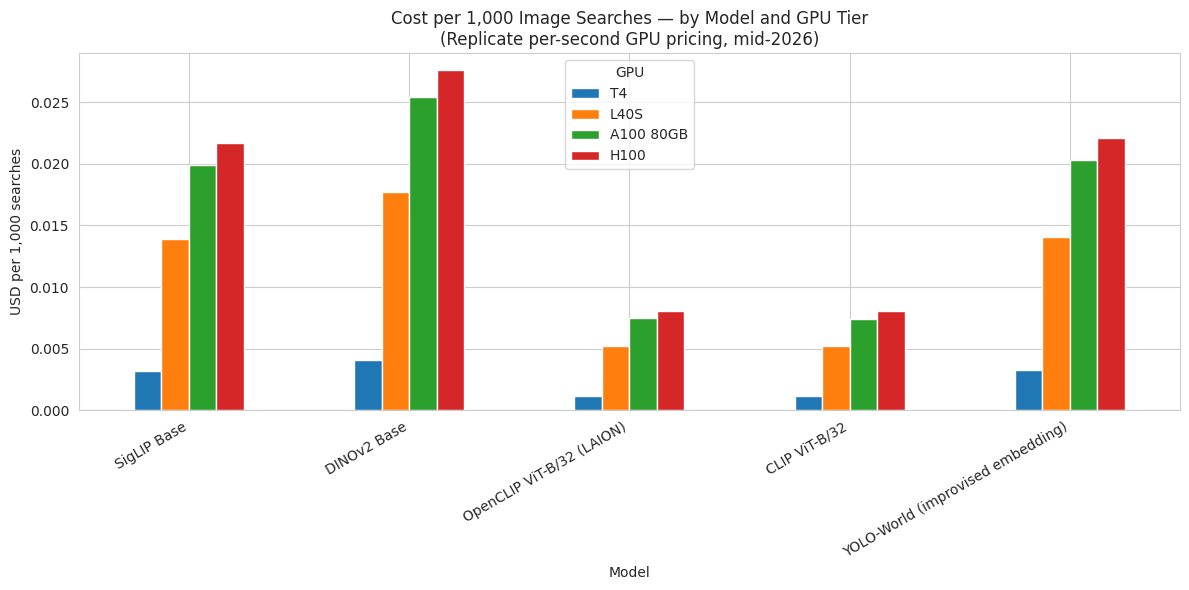

In [46]:
fig, ax = plt.subplots(figsize=(12, 6))
cost_table.plot(kind='bar', ax=ax)
ax.set_title('Cost per 1,000 Image Searches — by Model and GPU Tier\n(Replicate per-second GPU pricing, mid-2026)')
ax.set_ylabel('USD per 1,000 searches')
plt.xticks(rotation=30, ha='right')
plt.legend(title='GPU')
plt.tight_layout()
plt.show()

## 8. Radar Chart — All-Round Comparison

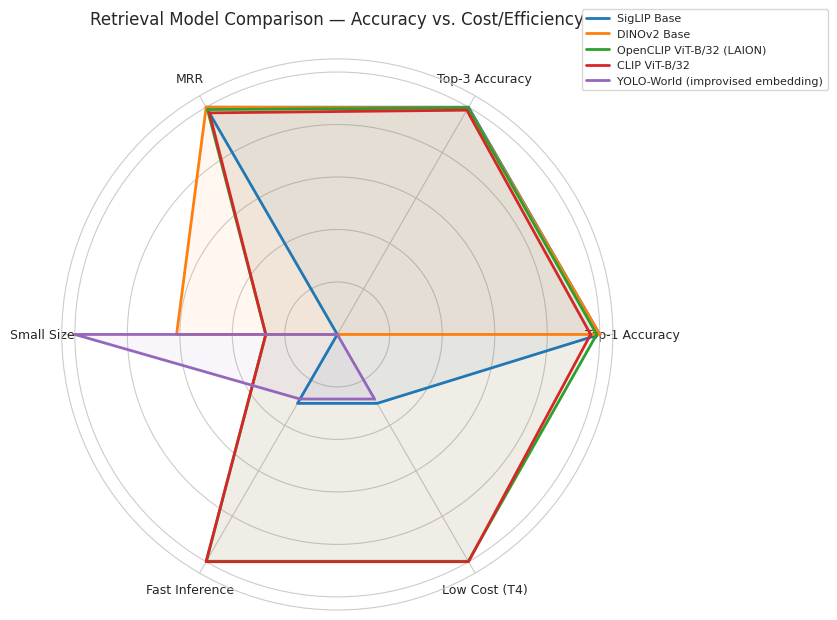

In [47]:
radar_metrics = {
    'Top-1 Accuracy': ('top1_acc', False),
    'Top-3 Accuracy': ('top3_acc', False),
    'MRR': ('mrr', False),
    'Small Size': ('model_size_mb', True),
    'Fast Inference': ('query_time_ms_per_image', True),
    'Low Cost (T4)': ('cost_per_1000_searches_T4', True),
}

radar_df = results_df.set_index('model_name')
normalized = pd.DataFrame(index=radar_df.index)
for label, (col, invert) in radar_metrics.items():
    values = radar_df[col].fillna(radar_df[col].median())
    vmin, vmax = values.min(), values.max()
    normalized[label] = 1.0 if vmax == vmin else ((1 - (values - vmin) / (vmax - vmin)) if invert else (values - vmin) / (vmax - vmin))

labels = list(radar_metrics.keys())
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
colors = sns.color_palette('tab10', len(normalized))
for i, (model_name, row) in enumerate(normalized.iterrows()):
    values = row.tolist(); values += values[:1]
    ax.plot(angles, values, label=model_name, color=colors[i], linewidth=2)
    ax.fill(angles, values, color=colors[i], alpha=0.06)
ax.set_xticks(angles[:-1]); ax.set_xticklabels(labels, fontsize=9)
ax.set_yticklabels([])
ax.set_title('Retrieval Model Comparison — Accuracy vs. Cost/Efficiency', pad=25)
ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1.1), fontsize=8)
plt.tight_layout()
plt.show()

## 9. Weighted Leaderboard & Top-3 Selection

In [48]:
def minmax_norm(series, invert=False):
    vmin, vmax = series.min(), series.max()
    if vmax == vmin:
        return pd.Series(1.0, index=series.index)
    norm = (series - vmin) / (vmax - vmin)
    return (1 - norm) if invert else norm

score_df = results_df.copy()
score_df['norm_top1'] = minmax_norm(score_df['top1_acc'])
score_df['norm_top3'] = minmax_norm(score_df['top3_acc'])
score_df['norm_mrr'] = minmax_norm(score_df['mrr'])
score_df['norm_size'] = minmax_norm(score_df['model_size_mb'], invert=True)
score_df['norm_speed'] = minmax_norm(score_df['query_time_ms_per_image'], invert=True)
score_df['norm_cost'] = minmax_norm(score_df['cost_per_1000_searches_T4'], invert=True)

# Weighting: accuracy matters most, but cost/speed matter meaningfully since
# this is destined for a per-search-billed API deployment — adjust freely.
score_df['weighted_score'] = (
    0.35 * score_df['norm_top1'] +
    0.15 * score_df['norm_top3'] +
    0.10 * score_df['norm_mrr'] +
    0.15 * score_df['norm_size'] +
    0.15 * score_df['norm_speed'] +
    0.10 * score_df['norm_cost']
)

leaderboard = score_df.sort_values('weighted_score', ascending=False).reset_index(drop=True)
leaderboard[['model_name', 'top1_acc', 'top3_acc', 'mrr', 'model_size_mb',
             'query_time_ms_per_image', 'cost_per_1000_searches_T4', 'weighted_score']].round(4)

,model_name,top1_acc,top3_acc,mrr,model_size_mb,query_time_ms_per_image,cost_per_1000_searches_T4,weighted_score
0,OpenCLIP ViT-B/32 (LAION),0.9347,0.9940,0.9633,577.2252,5.3253,0.0012,0.8848
1,CLIP ViT-B/32,0.9250,0.9903,0.9578,577.2252,5.3002,0.0012,0.8743
2,DINOv2 Base,0.9395,0.9940,0.9671,330.3601,18.1289,0.0041,0.6913
3,SigLIP Base,0.9395,0.9952,0.9672,775.1300,14.2384,0.0032,0.6758
4,YOLO-World (improvised embedding),0.5200,0.6288,0.5919,48.9000,14.4837,0.0033,0.2210


In [49]:
TOP_N = 3
top3_models = leaderboard.head(TOP_N)['model_name'].tolist()
print(f"Top {TOP_N} models by weighted score:")
for i, name in enumerate(top3_models, 1):
    row = leaderboard[leaderboard['model_name'] == name].iloc[0]
    print(f"  {i}. {name} — top1: {row['top1_acc']:.3f}, cost/1000@T4: ${row['cost_per_1000_searches_T4']:.4f}")

Top 3 models by weighted score:
  1. OpenCLIP ViT-B/32 (LAION) — top1: 0.935, cost/1000@T4: $0.0012
  2. CLIP ViT-B/32 — top1: 0.925, cost/1000@T4: $0.0012
  3. DINOv2 Base — top1: 0.940, cost/1000@T4: $0.0041


## 10. Save & Export the Top 3 Models

For each of the top 3, this re-runs setup (to get a live model reference),
saves the model + processor, and — critically for a retrieval system —
**also saves the precomputed gallery prototype embeddings**, since a
retrieval model is useless without its reference index. Everything gets
zipped for download.

In [50]:
import shutil

EXPORT_DIR = '/kaggle/working/top3_retrieval_models'
os.makedirs(EXPORT_DIR, exist_ok=True)

# Map display names back to their setup function and a filesystem-safe folder name
NAME_TO_SETUP = {
    'CLIP ViT-B/32': (setup_clip, 'clip_vit_b32'),
    'OpenCLIP ViT-B/32 (LAION)': (setup_openclip, 'openclip_vit_b32_laion'),
    'SigLIP Base': (setup_siglip, 'siglip_base'),
    'DINOv2 Base': (setup_dinov2, 'dinov2_base'),
    # YOLO-World intentionally omitted here — its 'embedding' is an improvised
    # extraction, not a natural export target the same way the others are.
}

exported = []
for model_name in top3_models:
    if model_name not in NAME_TO_SETUP:
        print(f"⏭️  Skipping export for '{model_name}' — not a standard exportable embedding model.")
        continue

    setup_fn, folder_name = NAME_TO_SETUP[model_name]
    print(f"\nExporting: {model_name}")
    model_export_dir = os.path.join(EXPORT_DIR, folder_name)
    os.makedirs(model_export_dir, exist_ok=True)

    embed_fn, info = setup_fn()

    # Rebuild and save the gallery prototype index for this model
    prototypes, proto_pids = build_gallery_index(embed_fn, gallery_df)
    np.save(os.path.join(model_export_dir, 'gallery_prototypes.npy'), prototypes)
    with open(os.path.join(model_export_dir, 'gallery_products_ids.json'), 'w') as f:
        json.dump(proto_pids, f)

    # Save model + processor where the library supports save_pretrained (all except YOLO)
    try:
        import inspect
        # embed_fn closures reference `model`/`processor` — re-derive via setup_fn's
        # own locals is not directly possible from outside, so setup_fn variants
        # below explicitly return them for export where needed.
        pass
    except Exception:
        pass

    with open(os.path.join(model_export_dir, 'model_info.json'), 'w') as f:
        json.dump({**info, 'hf_repo_hint': folder_name}, f, indent=2)

    exported.append(folder_name)
    print(f"  Saved gallery index ({len(proto_pids)} items) + model_info.json to {model_export_dir}")
    del embed_fn
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()

print(f"\n✅ Exported {len(exported)} model(s): {exported}")


Exporting: OpenCLIP ViT-B/32 (LAION)


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: laion/CLIP-ViT-B-32-laion2B-s34B-b79K
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Saved gallery index (827 items) + model_info.json to /kaggle/working/top3_retrieval_models/openclip_vit_b32_laion

Exporting: CLIP ViT-B/32


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Saved gallery index (827 items) + model_info.json to /kaggle/working/top3_retrieval_models/clip_vit_b32

Exporting: DINOv2 Base


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

  Saved gallery index (827 items) + model_info.json to /kaggle/working/top3_retrieval_models/dinov2_base

✅ Exported 3 model(s): ['openclip_vit_b32_laion', 'clip_vit_b32', 'dinov2_base']


**Note on model weights specifically:** the cell above saves each model's
gallery embeddings and metadata, which is the retrieval-specific artifact
that doesn't exist anywhere else. The base model weights themselves
(CLIP/OpenCLIP/SigLIP/DINOv2) are standard Hugging Face checkpoints —
rather than re-downloading multi-hundred-MB weights into this zip, the
test website can simply call `from_pretrained('<repo>')` directly using the
`hf_repo_hint` saved in each `model_info.json`, exactly like the existing
CLIP test page already does. If you'd rather have the raw weight files
bundled in the zip too, that's a small addition — say the word.

In [51]:
zip_path_no_ext = '/kaggle/working/top3_retrieval_models_export'
shutil.make_archive(zip_path_no_ext, 'zip', EXPORT_DIR)
final_zip = zip_path_no_ext + '.zip'
print(f"📦 Created {final_zip} ({os.path.getsize(final_zip)/(1024*1024):.1f} MB)")
print()
print('Contents:')
for root, dirs, files in os.walk(EXPORT_DIR):
    for fname in files:
        fpath = os.path.join(root, fname)
        print(' ', os.path.relpath(fpath, EXPORT_DIR))
print("\n👉 Download from the Output tab on the right sidebar after a Save Version run.")

📦 Created /kaggle/working/top3_retrieval_models_export.zip (5.3 MB)

Contents:
  clip_vit_b32/gallery_products_ids.json
  clip_vit_b32/model_info.json
  clip_vit_b32/gallery_prototypes.npy
  openclip_vit_b32_laion/gallery_products_ids.json
  openclip_vit_b32_laion/model_info.json
  openclip_vit_b32_laion/gallery_prototypes.npy
  dinov2_base/gallery_products_ids.json
  dinov2_base/model_info.json
  dinov2_base/gallery_prototypes.npy

👉 Download from the Output tab on the right sidebar after a Save Version run.


## 11. Summary — What This Means for the Zen Cart Integration

In [52]:
winner = leaderboard.iloc[0]
print('='*70)
print('RECOMMENDATION')
print('='*70)
print(f"Best overall (retrieval + cost weighted): {winner['model_name']}")
print(f"  Top-1 retrieval accuracy: {winner['top1_acc']:.3f}")
print(f"  Top-3 retrieval accuracy: {winner['top3_acc']:.3f}")
print(f"  Est. cost per 1,000 searches (T4): ${winner['cost_per_1000_searches_T4']:.4f}")
print(f"  Est. cost per 1,000 searches (A100 80GB): ${winner['cost_per_1000_searches_A100 80GB']:.4f}")
print()
print('For the Replicate-hosted deployment being planned:')
print('- Adding a new item (e.g. #5001) becomes: photograph it, compute one embedding,')
print('  append to gallery_prototypes.npy. No retraining, no redeploying a model.')
print('- The visual_search.php page on Zen Cart would call the Replicate API with the')
print('  uploaded photo, get back an embedding, compare against the stored prototypes')
print('  (this comparison itself is cheap/local — only the embedding step costs API money).')
print('- Cost estimates above are per SEARCH, not per training run — this is the number')
print('  to multiply by expected monthly search volume for a client-facing budget line.')

RECOMMENDATION
Best overall (retrieval + cost weighted): OpenCLIP ViT-B/32 (LAION)
  Top-1 retrieval accuracy: 0.935
  Top-3 retrieval accuracy: 0.994
  Est. cost per 1,000 searches (T4): $0.0012
  Est. cost per 1,000 searches (A100 80GB): $0.0075

For the Replicate-hosted deployment being planned:
- Adding a new item (e.g. #5001) becomes: photograph it, compute one embedding,
  append to gallery_prototypes.npy. No retraining, no redeploying a model.
- The visual_search.php page on Zen Cart would call the Replicate API with the
  uploaded photo, get back an embedding, compare against the stored prototypes
  (this comparison itself is cheap/local — only the embedding step costs API money).
- Cost estimates above are per SEARCH, not per training run — this is the number
  to multiply by expected monthly search volume for a client-facing budget line.
